# E-Commerce Dark Patterns Detection Pipeline

**Author:** Balaji N (CB.SC.U4CSE23011)  
**Course:** Business Analytics - 23CSE452  

---

This notebook runs the complete dark patterns analysis pipeline end-to-end:

1. **Data Collection** - Scrapes product listings from Amazon, Flipkart, and Snapdeal
2. **Preprocessing** - Cleans raw data and engineers 18 features
3. **Labeling** - Semi-automated risk classification (High / Medium / Low)
4. **EDA** - Generates comprehensive visualizations
5. **Model Training** - Trains 4 classifiers with hyperparameter tuning
6. **Evaluation** - Selects the best model by weighted F1-score
7. **Report Generation** - Produces an analytics report in Markdown

## Setup

Make sure all dependencies are installed before running:

```bash
pip install -r requirements.txt
```

In [12]:
import sys
import os
import io

# Force UTF-8 output on Windows
if hasattr(sys.stdout, 'buffer'):
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8', errors='replace')
    sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding='utf-8', errors='replace')

# Add the src/ directory to the Python path so imports resolve
SRC_DIR = os.path.join(os.path.abspath('.'), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import config
print(f'Project root : {config.BASE_DIR}')
print(f'Source dir   : {config.SRC_DIR}')
print(f'Data dir     : {config.DATA_DIR}')
print('\nSetup complete. All paths resolved.')

Project root : d:\Study Material\BA\Dark Patterns
Source dir   : d:\Study Material\BA\Dark Patterns\src
Data dir     : d:\Study Material\BA\Dark Patterns\data

Setup complete. All paths resolved.


---
## Helper: Phase Runner

A small utility to run each pipeline phase with status reporting.

In [13]:
def run_phase(name, func):
    """Run a pipeline phase with error handling."""
    print(f"\n{'+'+ '-'*58 + '+'}")
    print(f"|  PHASE: {name:<49}|")
    print(f"{'+'+ '-'*58 + '+'}\n")
    try:
        result = func()
        print(f"\n[OK] {name} -- COMPLETE")
        return result
    except Exception as e:
        print(f"\n[FAIL] {name} -- FAILED: {e}")
        import traceback
        traceback.print_exc()
        return None

---
## Phase 1 & 2: Data Collection (Web Scraping)

Scrapes product listings from **Amazon India**, **Flipkart**, and **Snapdeal** across 6 product categories.

> **Note:** This step requires an internet connection and may take **5-10 minutes**.
> If scraping has already been completed, the raw CSV files in `data/raw/` will be used.

In [14]:
from scrape_all import main as scrape_main
run_phase('Data Collection (Scraping)', scrape_main)


+----------------------------------------------------------+
|  PHASE: Data Collection (Scraping)                       |
+----------------------------------------------------------+

LIVE E-COMMERCE SCRAPING PIPELINE (ALL PLATFORMS)
✓ Found verified live scraped datasets: Flipkart (278), Amazon (260), Snapdeal (208)
  Merging and validating...
  Flipkart:  278 genuine listings
  Amazon:    260 genuine listings
  Snapdeal:  208 genuine listings

✓ Merged dataset: 744 live scraped listings → d:\Study Material\BA\Dark Patterns\data\raw_merged.csv

[OK] Data Collection (Scraping) -- COMPLETE


,platform,category,product_name,selling_price,original_price,discount_percentage,rating,rating_count,review_count,seller_name,...,is_sponsored,promotional_badges,promotional_badge_count,scarcity_message,has_scarcity_message,has_coupon,coupon_text,return_policy,has_return_policy,product_url
0,Flipkart,electronics,"Ai+ Nova 2 5G (Blue, 128 GB)",12600.0,14999.0,16.0,4.1,5170,387,NaN,...,False,NaN,0,NaN,False,True,Bank/Coupon Offer Available,7 days replacement,True,https://www.flipkart.com/ai-nova-2-5g-blue-128...
1,Flipkart,electronics,"Samsung Galaxy F07 (Green, 64 GB)",9300.0,11999.0,22.5,4.2,10294,739,NaN,...,False,Bestseller,1,NaN,False,True,Bank/Coupon Offer Available,7 days replacement,True,https://www.flipkart.com/samsung-galaxy-f07-gr...
2,Flipkart,electronics,"REDMI A7 Pro 5G (Black, 64 GB)",11750.0,15999.0,9.0,4.0,3789,320,NaN,...,False,NaN,0,NaN,False,True,Bank/Coupon Offer Available,7 days replacement,True,https://www.flipkart.com/redmi-a7-pro-5g-black...
3,Flipkart,electronics,"realme Narzo 80 Lite (Obsidian Black, 64 GB)",9650.0,16999.0,21.0,4.2,3338,177,NaN,...,False,NaN,0,Only Few Left,True,False,NaN,7 days replacement,True,https://www.flipkart.com/realme-narzo-80-lite-...
4,Flipkart,electronics,"Ai+ Nova 2 5G (Black, 128 GB)",12600.0,14999.0,16.0,4.1,5170,387,NaN,...,False,NaN,0,NaN,False,True,Bank/Coupon Offer Available,7 days replacement,True,https://www.flipkart.com/ai-nova-2-5g-black-12...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
741,Snapdeal,wearables,"Resistance Bands 11 pcs Set, Stretching and Ex...",307.0,1299.0,76.0,4.1,196,39,NaN,...,False,Great Offer,1,Limited Period Offer,True,False,NaN,7 days return,True,https://www.snapdeal.com/product/resistance-ba...
742,Snapdeal,wearables,"Resistance Hip Loop Bands for Legs, Butt, Thig...",200.0,599.0,67.0,5.0,183,36,NaN,...,False,Great Offer,1,NaN,False,False,NaN,7 days return,True,https://www.snapdeal.com/product/resistance-hi...
743,Snapdeal,wearables,ProTone Triple Tube Resistance Band with Ergon...,361.0,999.0,64.0,4.0,157,31,NaN,...,False,NaN,0,NaN,False,False,NaN,7 days return,True,https://www.snapdeal.com/product/protone-tripl...
744,Snapdeal,wearables,Home Gym Resistance Bands 11 PCS Set for Wor...,314.0,1099.0,71.0,4.0,106,21,NaN,...,False,Great Offer,1,Limited Period Offer,True,False,NaN,7 days return,True,https://www.snapdeal.com/product/home-gym-resi...


---
## Phase 3: Data Preprocessing & Feature Engineering

Cleans the raw data and engineers 18 features including composite scores:
- `promotional_intensity`, `price_rating_mismatch`
- `review_to_rating_ratio`, `urgency_score`, `trust_score`

In [15]:
from preprocessing import main as preprocess_main
run_phase('Data Preprocessing & Feature Engineering', preprocess_main)


+----------------------------------------------------------+
|  PHASE: Data Preprocessing & Feature Engineering         |
+----------------------------------------------------------+

╔══════════════════════════════════════════════════════════╗
║  Data Preprocessing & Feature Engineering                ║
╚══════════════════════════════════════════════════════════╝

Loaded 744 raw records from d:\Study Material\BA\Dark Patterns\data\raw_merged.csv

── Data Cleaning ──────────────────────────────────────────
  Removed 131 duplicates → 613 records
  After cleaning: 613 records, 24 columns

── Feature Engineering ─────────────────────────────────────
  ✓ promotional_intensity (sum of all promotional cues)
  ✓ price_rating_mismatch (discount × inverse rating)
  ✓ review_to_rating_ratio (reviews / ratings, clipped 0-1)
  ✓ urgency_score (weighted: scarcity×3 + extreme_discount×2 + coupon + rush_delivery)
  ✓ trust_score (composite: rating, reviews, returns, minus suspicion)

  Final feature

,platform,category,product_name,selling_price,original_price,discount_percentage,rating,rating_count,review_count,seller_name,...,has_coupon,coupon_text,return_policy,has_return_policy,product_url,promotional_intensity,price_rating_mismatch,review_to_rating_ratio,urgency_score,trust_score
0,Flipkart,electronics,"Ai+ Nova 2 5G (Blue, 128 GB)",12600.0,14999.0,16.0,4.1,5170,387,NaN,...,1,Bank/Coupon Offer Available,7 days replacement,1,https://www.flipkart.com/ai-nova-2-5g-blue-128...,1,0.029,0.075,1,4.140
1,Flipkart,electronics,"Samsung Galaxy F07 (Green, 64 GB)",9300.0,11999.0,22.5,4.2,10294,739,NaN,...,1,Bank/Coupon Offer Available,7 days replacement,1,https://www.flipkart.com/samsung-galaxy-f07-gr...,2,0.036,0.072,1,4.180
2,Flipkart,electronics,"REDMI A7 Pro 5G (Black, 64 GB)",11750.0,15999.0,9.0,4.0,3789,320,NaN,...,1,Bank/Coupon Offer Available,7 days replacement,1,https://www.flipkart.com/redmi-a7-pro-5g-black...,1,0.018,0.084,1,4.100
3,Flipkart,electronics,"realme Narzo 80 Lite (Obsidian Black, 64 GB)",9650.0,16999.0,21.0,4.2,3338,177,NaN,...,0,NaN,7 days replacement,1,https://www.flipkart.com/realme-narzo-80-lite-...,1,0.034,0.053,3,4.180
4,Flipkart,electronics,"Ai+ Nova 2 5G (Black, 128 GB)",12600.0,14999.0,16.0,4.1,5170,387,NaN,...,1,Bank/Coupon Offer Available,7 days replacement,1,https://www.flipkart.com/ai-nova-2-5g-black-12...,1,0.029,0.075,1,4.140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
738,Snapdeal,wearables,Double Toning Tube Resistance Band for Workout...,175.0,599.0,71.0,5.0,74,14,NaN,...,0,NaN,7 days return,1,https://www.snapdeal.com/product/double-toning...,2,0.000,0.189,5,4.363
739,Snapdeal,wearables,"Resistance Bands 11 pcs Set, Stretching and Ex...",307.0,1299.0,76.0,4.1,196,39,NaN,...,0,NaN,7 days return,1,https://www.snapdeal.com/product/resistance-ba...,2,0.137,0.199,5,4.140
741,Snapdeal,wearables,ProTone Triple Tube Resistance Band with Ergon...,361.0,999.0,64.0,4.0,157,31,NaN,...,0,NaN,7 days return,1,https://www.snapdeal.com/product/protone-tripl...,0,0.128,0.197,2,5.100
742,Snapdeal,wearables,Home Gym Resistance Bands 11 PCS Set for Wor...,314.0,1099.0,71.0,4.0,106,21,NaN,...,0,NaN,7 days return,1,https://www.snapdeal.com/product/home-gym-resi...,2,0.142,0.198,5,4.035


---
## Phase 4: Semi-Automated Labeling

Applies rule-based labeling for clear-cut High/Low risk cases, then uses heuristic scoring for ambiguous Medium cases.

In [16]:
from labeling import main as label_main
run_phase('Semi-Automated Labeling', label_main)


+----------------------------------------------------------+
|  PHASE: Semi-Automated Labeling                          |
+----------------------------------------------------------+

╔══════════════════════════════════════════════════════════╗
║  Semi-Automated Labeling Pipeline                        ║
╚══════════════════════════════════════════════════════════╝

Loaded 613 processed records

── Applying Rule-Based Labels ──────────────────────────────

  HIGH RISK (≥3 flags): 154 listings
    Flag breakdown:
      extreme_discount: 273 listings triggered
      scarcity: 182 listings triggered
      multi_badge: 8 listings triggered
      sponsored: 88 listings triggered
      coupon: 89 listings triggered
      no_return: 0 listings triggered
      low_reviews_high_discount: 279 listings triggered

  LOW RISK (all conditions met): 50 listings

  MEDIUM (ambiguous → manual review): 409 listings

── Auto-Resolving Medium Cases (Heuristic) ─────────────────

  Resolved 409 medium case

,platform,category,product_name,selling_price,original_price,discount_percentage,rating,rating_count,review_count,seller_name,...,has_return_policy,product_url,promotional_intensity,price_rating_mismatch,review_to_rating_ratio,urgency_score,trust_score,manipulation_risk,auto_labeled,flag_count
0,Flipkart,electronics,"Ai+ Nova 2 5G (Blue, 128 GB)",12600.0,14999.0,16.0,4.1,5170,387,NaN,...,1,https://www.flipkart.com/ai-nova-2-5g-blue-128...,1,0.029,0.075,1,4.140,Low,True,1
1,Flipkart,electronics,"Samsung Galaxy F07 (Green, 64 GB)",9300.0,11999.0,22.5,4.2,10294,739,NaN,...,1,https://www.flipkart.com/samsung-galaxy-f07-gr...,2,0.036,0.072,1,4.180,Medium,False,1
2,Flipkart,electronics,"REDMI A7 Pro 5G (Black, 64 GB)",11750.0,15999.0,9.0,4.0,3789,320,NaN,...,1,https://www.flipkart.com/redmi-a7-pro-5g-black...,1,0.018,0.084,1,4.100,Low,True,1
3,Flipkart,electronics,"realme Narzo 80 Lite (Obsidian Black, 64 GB)",9650.0,16999.0,21.0,4.2,3338,177,NaN,...,1,https://www.flipkart.com/realme-narzo-80-lite-...,1,0.034,0.053,3,4.180,High,False,1
4,Flipkart,electronics,"Ai+ Nova 2 5G (Black, 128 GB)",12600.0,14999.0,16.0,4.1,5170,387,NaN,...,1,https://www.flipkart.com/ai-nova-2-5g-black-12...,1,0.029,0.075,1,4.140,Low,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,Snapdeal,wearables,Double Toning Tube Resistance Band for Workout...,175.0,599.0,71.0,5.0,74,14,NaN,...,1,https://www.snapdeal.com/product/double-toning...,2,0.000,0.189,5,4.363,High,True,3
609,Snapdeal,wearables,"Resistance Bands 11 pcs Set, Stretching and Ex...",307.0,1299.0,76.0,4.1,196,39,NaN,...,1,https://www.snapdeal.com/product/resistance-ba...,2,0.137,0.199,5,4.140,High,True,3
610,Snapdeal,wearables,ProTone Triple Tube Resistance Band with Ergon...,361.0,999.0,64.0,4.0,157,31,NaN,...,1,https://www.snapdeal.com/product/protone-tripl...,0,0.128,0.197,2,5.100,Medium,False,1
611,Snapdeal,wearables,Home Gym Resistance Bands 11 PCS Set for Wor...,314.0,1099.0,71.0,4.0,106,21,NaN,...,1,https://www.snapdeal.com/product/home-gym-resi...,2,0.142,0.198,5,4.035,High,True,3


---
## Phase 5: Exploratory Data Analysis

Generates 10 visualizations covering risk distribution, platform comparison, feature correlations, and more.

Charts are saved to `src/output/charts/`.

In [17]:
from eda import main as eda_main
run_phase('Exploratory Data Analysis', eda_main)


+----------------------------------------------------------+
|  PHASE: Exploratory Data Analysis                        |
+----------------------------------------------------------+

╔══════════════════════════════════════════════════════════╗
║  Exploratory Data Analysis (EDA)                         ║
╚══════════════════════════════════════════════════════════╝

Loaded 613 labeled records

Generating charts...

  ✓ Saved: 01_risk_distribution.png
  ✓ Saved: 02_risk_by_platform.png
  ✓ Saved: 03_risk_by_category.png
  ✓ Saved: 04_discount_distribution.png
  ✓ Saved: 05_rating_vs_discount.png
  ✓ Saved: 06_correlation_heatmap.png
  ✓ Saved: 07_promotional_intensity.png
  ✓ Saved: 08_trust_vs_urgency.png
  ✓ Saved: 09_price_analysis.png
  ✓ Saved: 10_feature_distributions.png

✓ Generated 10 charts in d:\Study Material\BA\Dark Patterns\src\output\charts

DATASET SUMMARY
Total listings: 613
Platforms: 3 (Flipkart, Amazon, Snapdeal)
Categories: 4 (electronics, fashion, audio, wearables)

['d:\\Study Material\\BA\\Dark Patterns\\src\\output\\charts\\01_risk_distribution.png',
 'd:\\Study Material\\BA\\Dark Patterns\\src\\output\\charts\\02_risk_by_platform.png',
 'd:\\Study Material\\BA\\Dark Patterns\\src\\output\\charts\\03_risk_by_category.png',
 'd:\\Study Material\\BA\\Dark Patterns\\src\\output\\charts\\04_discount_distribution.png',
 'd:\\Study Material\\BA\\Dark Patterns\\src\\output\\charts\\05_rating_vs_discount.png',
 'd:\\Study Material\\BA\\Dark Patterns\\src\\output\\charts\\06_correlation_heatmap.png',
 'd:\\Study Material\\BA\\Dark Patterns\\src\\output\\charts\\07_promotional_intensity.png',
 'd:\\Study Material\\BA\\Dark Patterns\\src\\output\\charts\\08_trust_vs_urgency.png',
 'd:\\Study Material\\BA\\Dark Patterns\\src\\output\\charts\\09_price_analysis.png',
 'd:\\Study Material\\BA\\Dark Patterns\\src\\output\\charts\\10_feature_distributions.png']

### Preview EDA Charts


01_risk_distribution.png


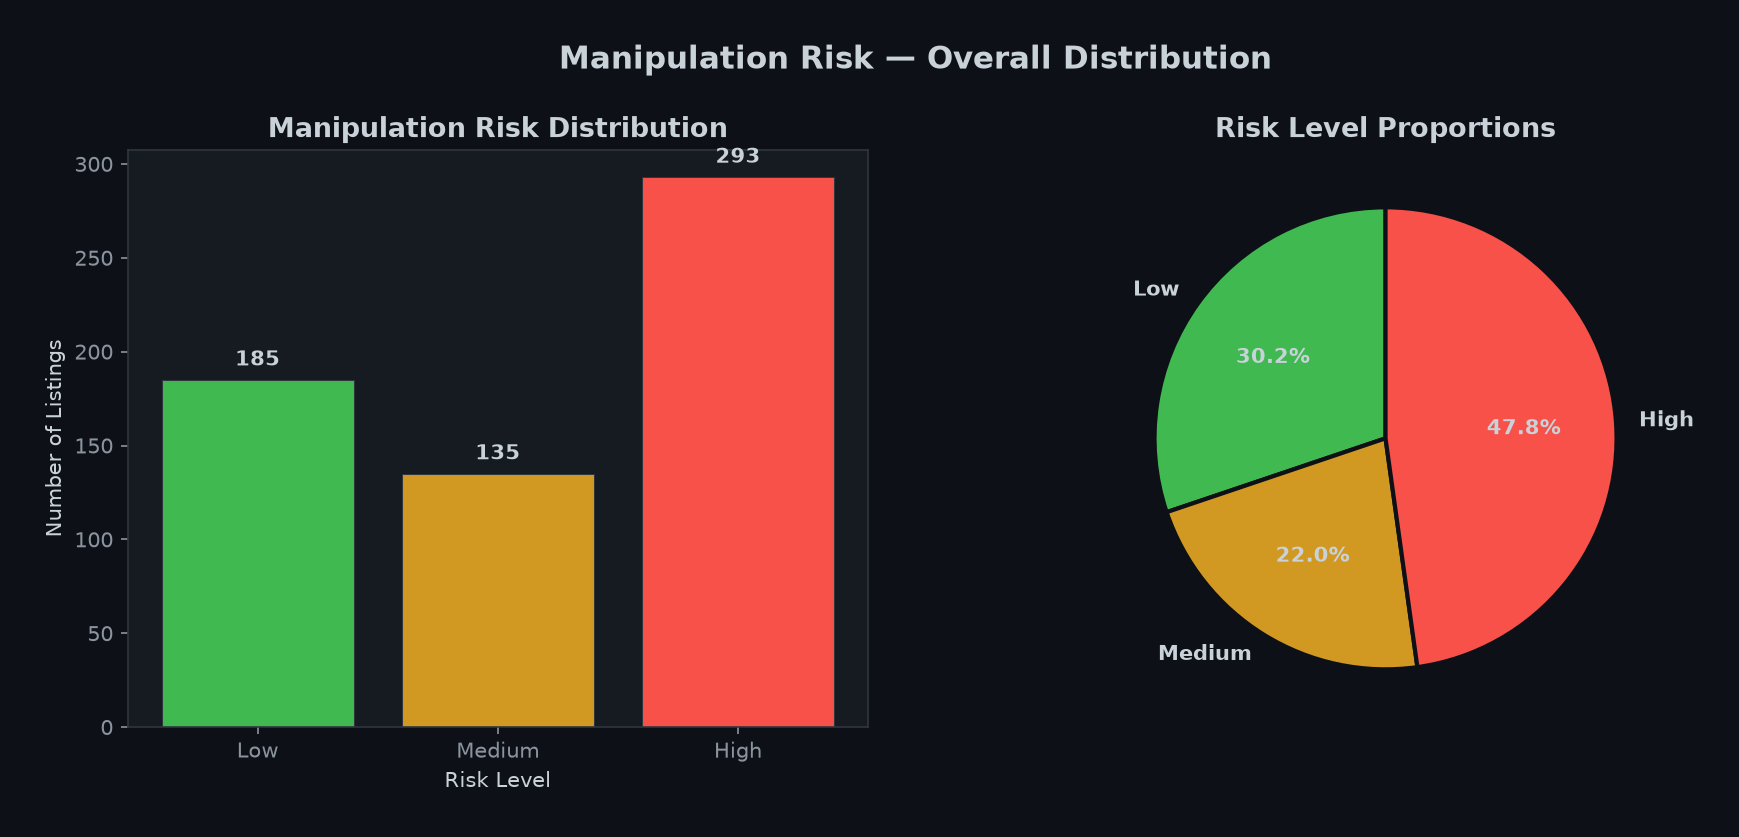


02_risk_by_platform.png


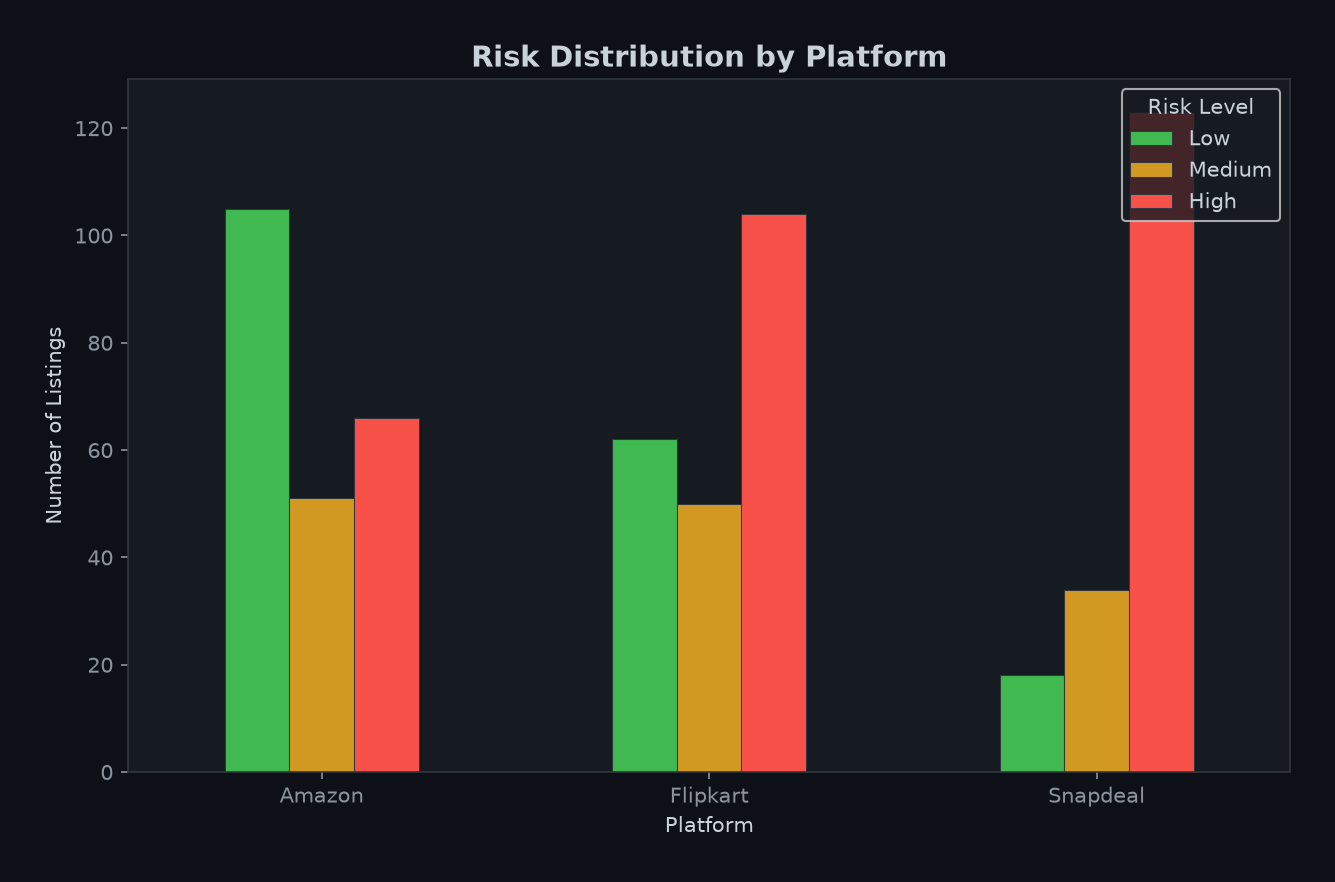


03_risk_by_category.png


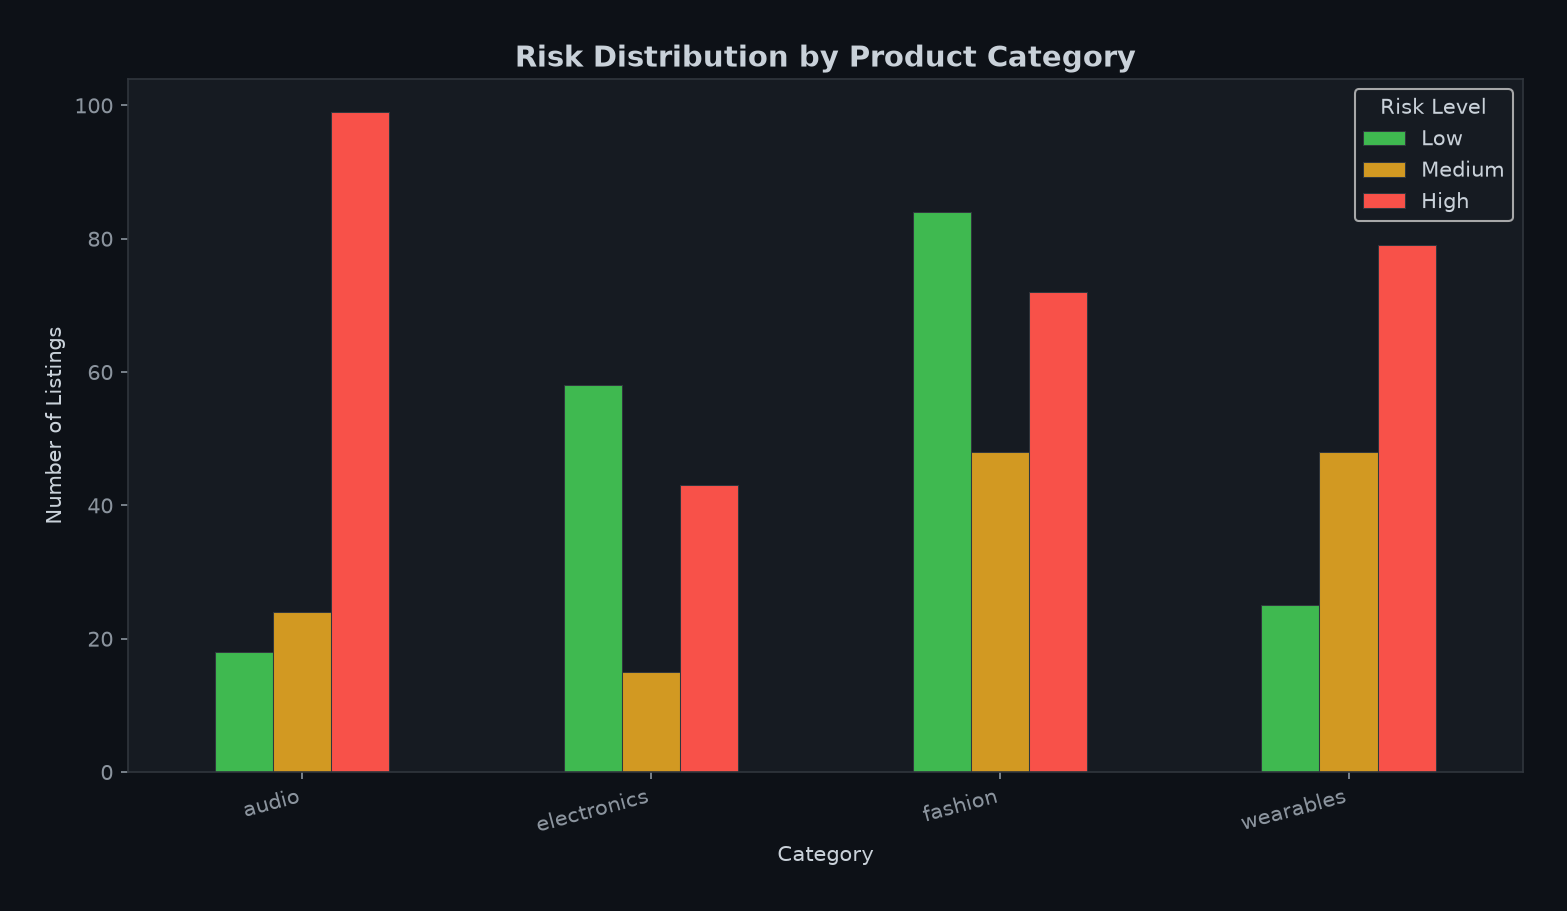


04_discount_distribution.png


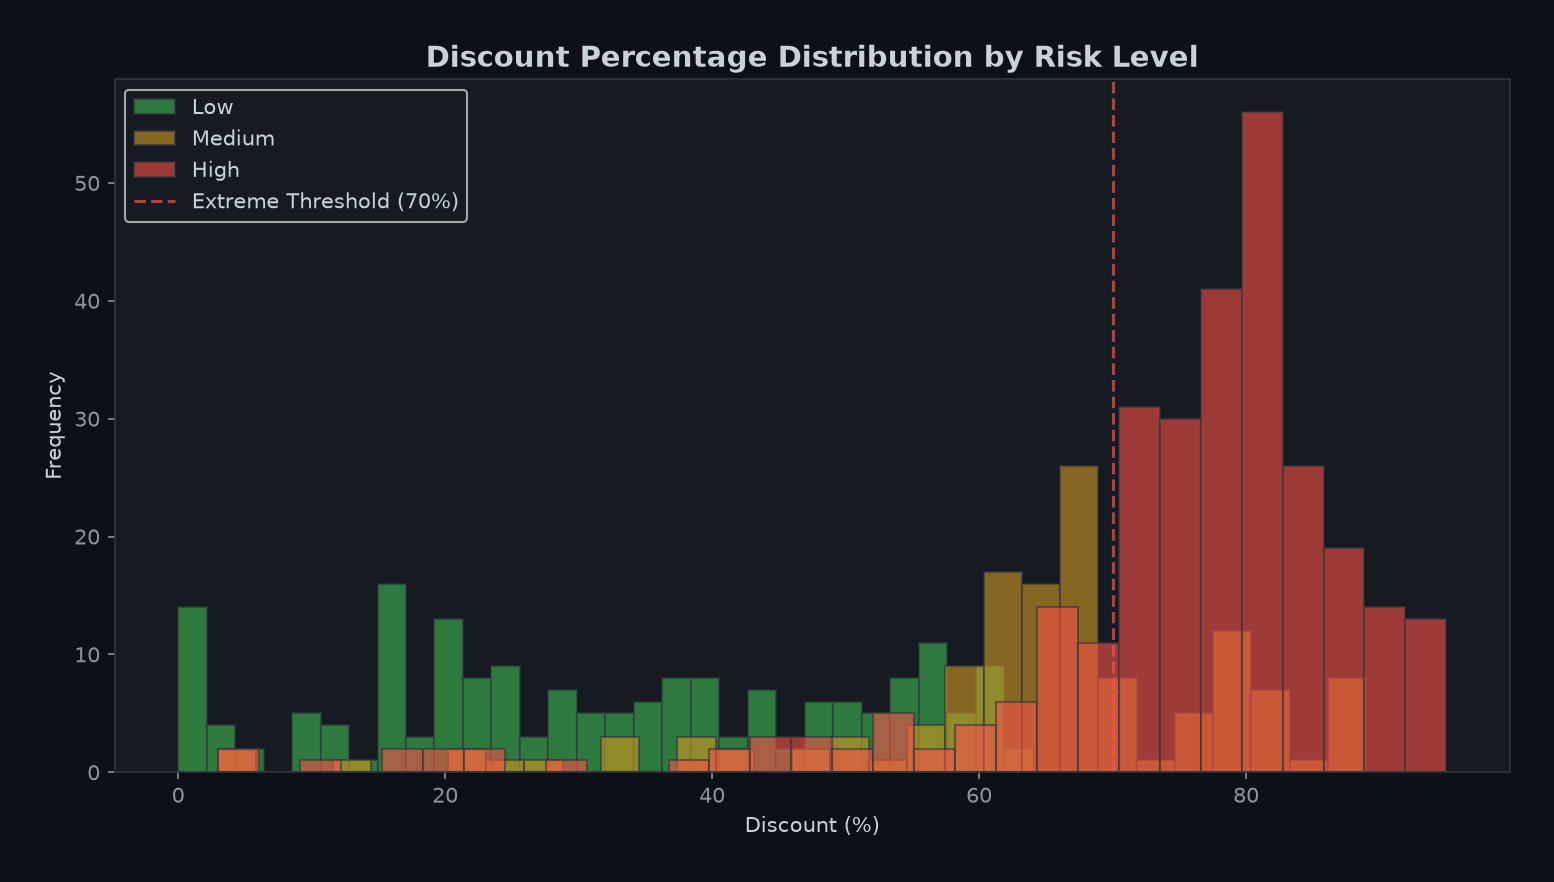


05_rating_vs_discount.png


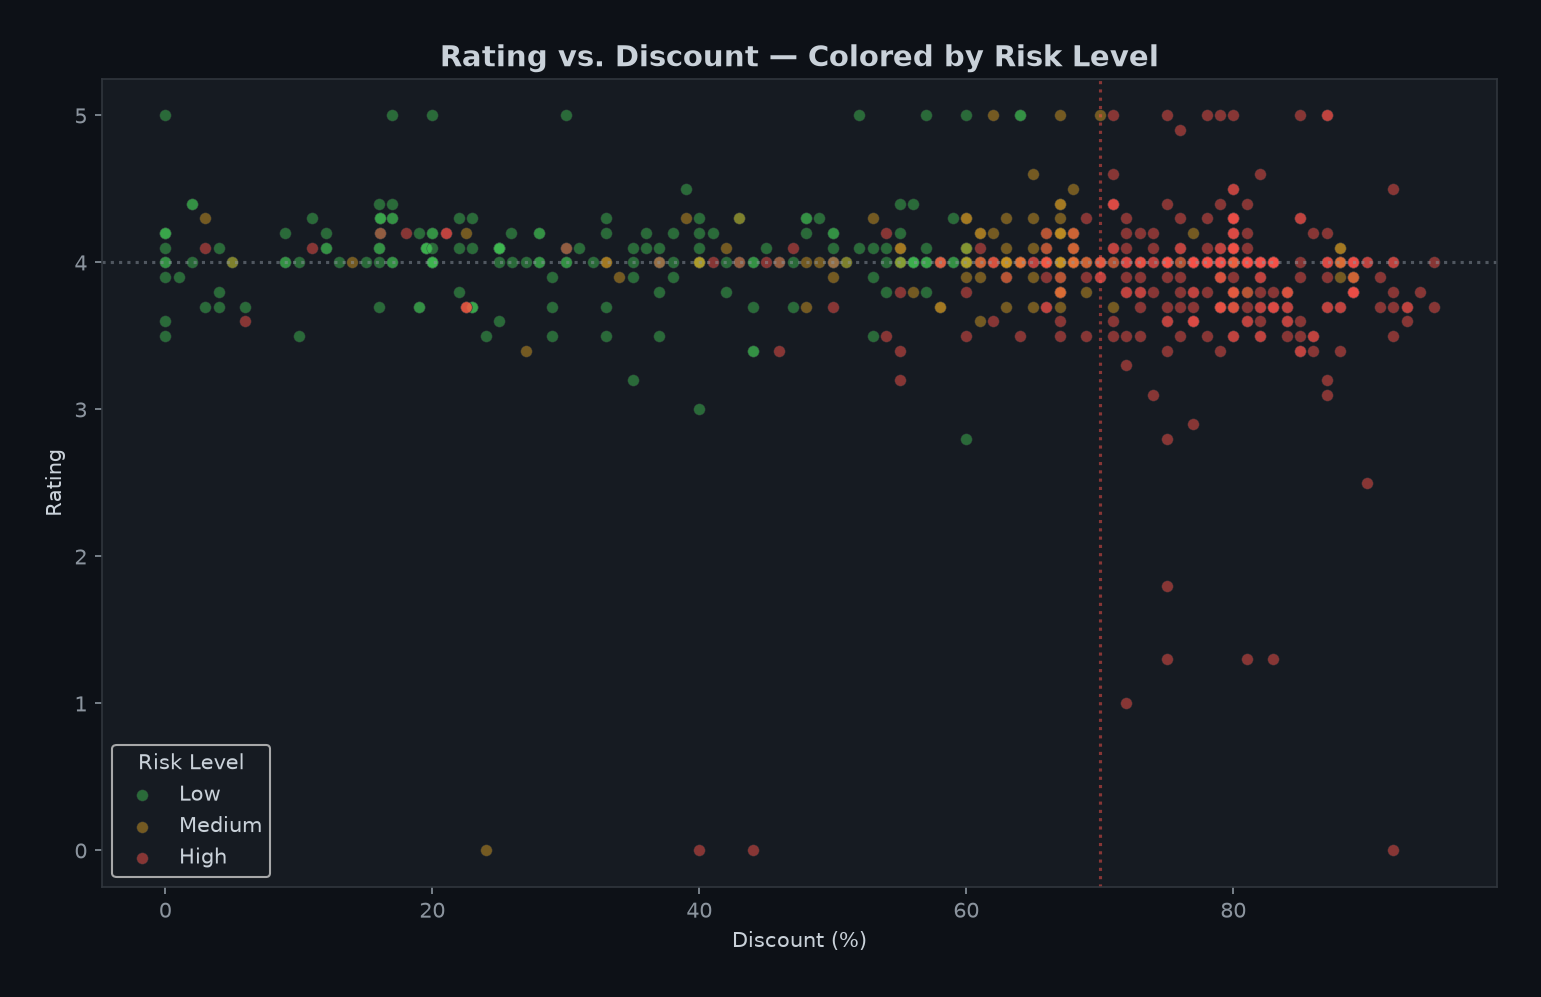


06_correlation_heatmap.png


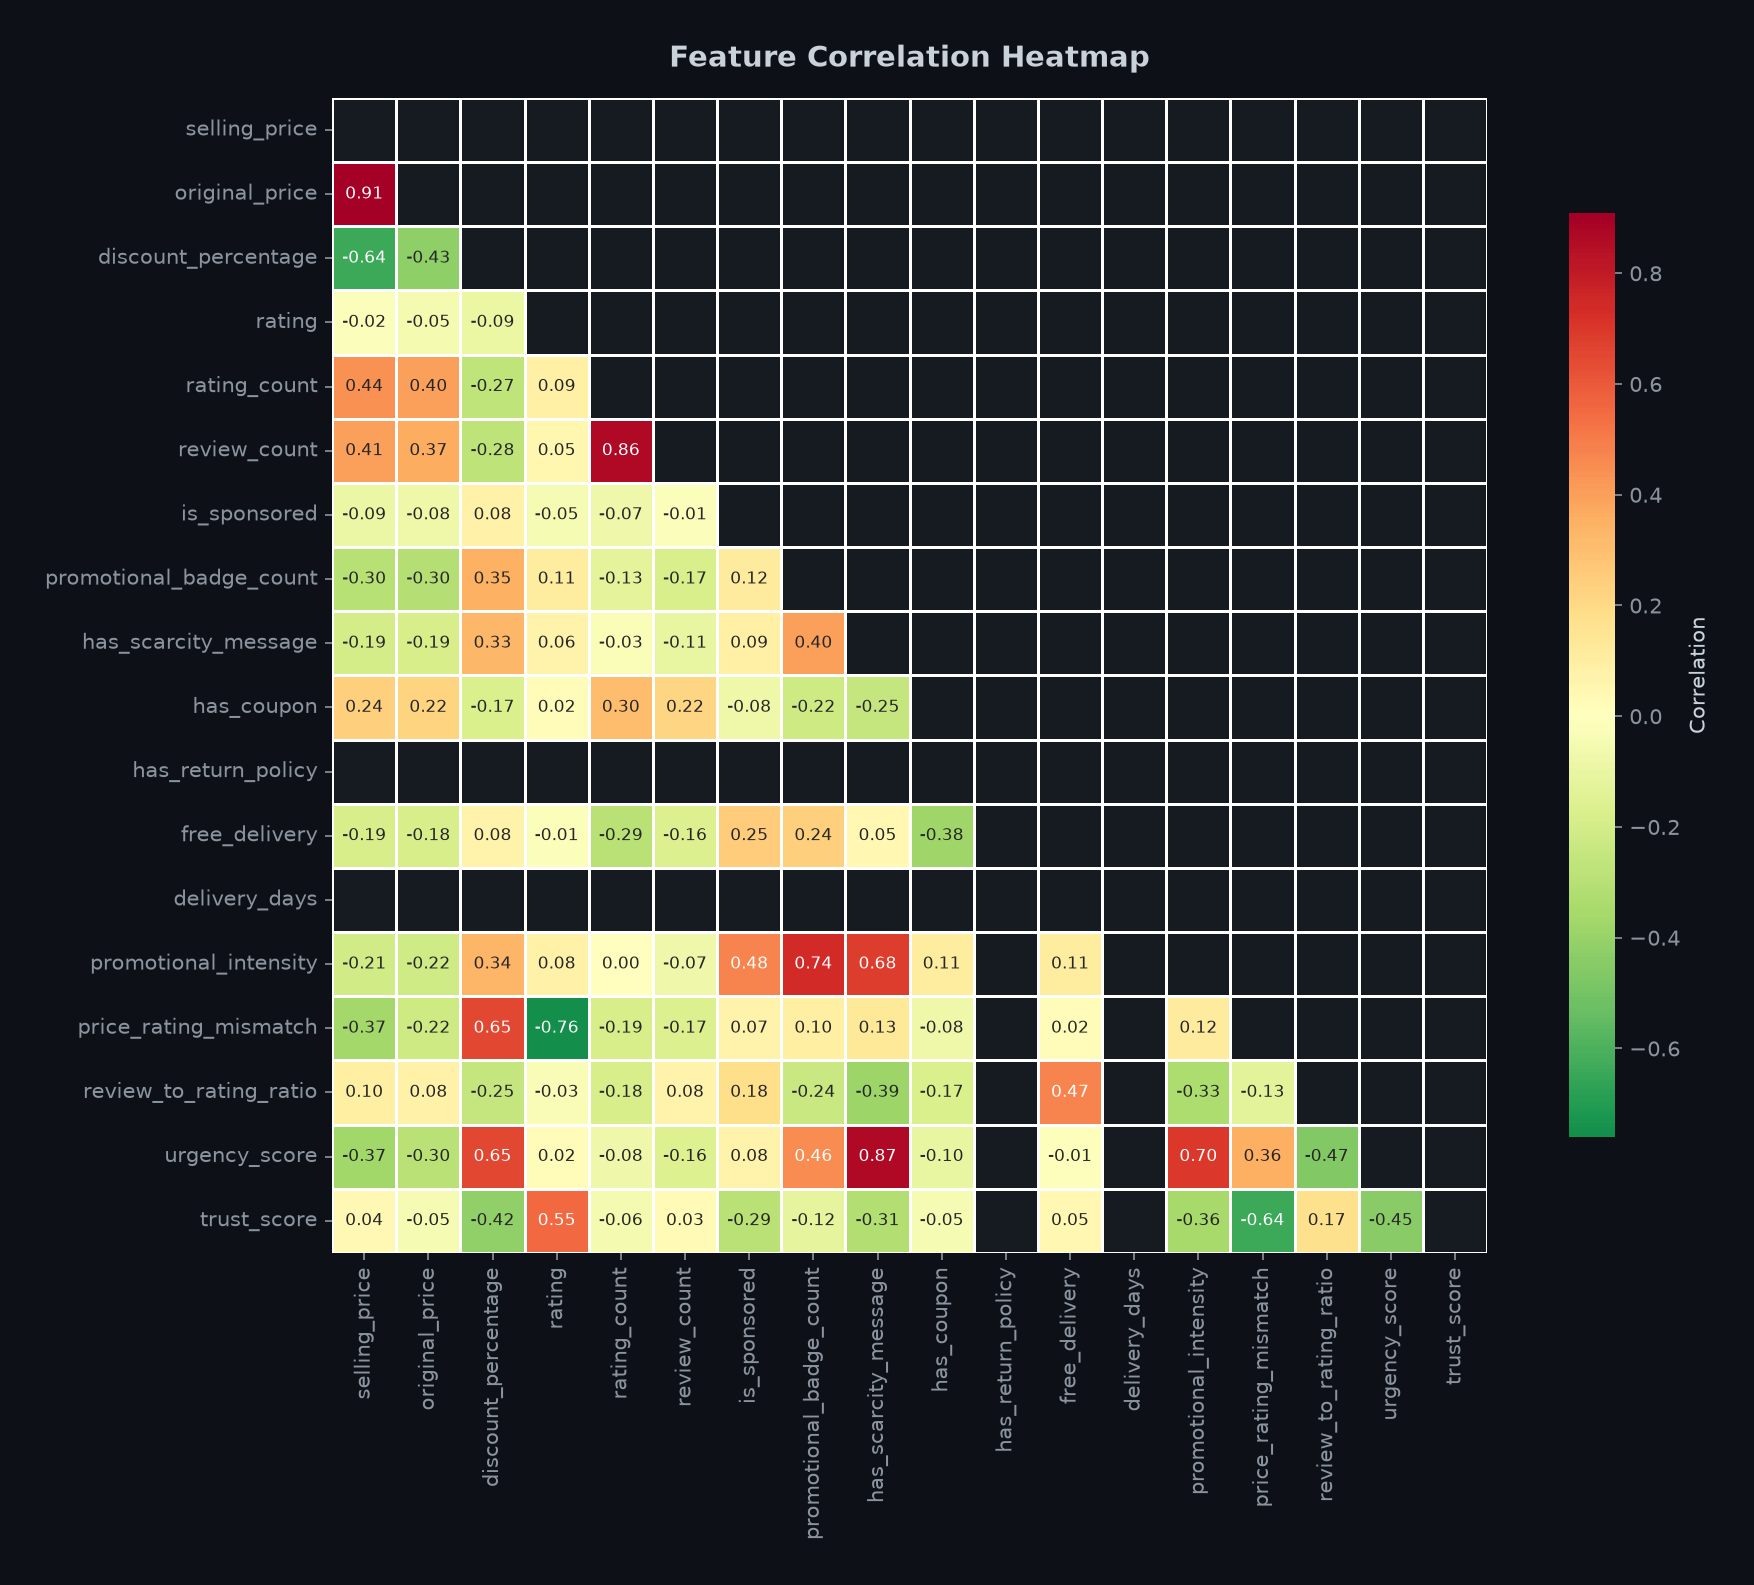


07_promotional_intensity.png


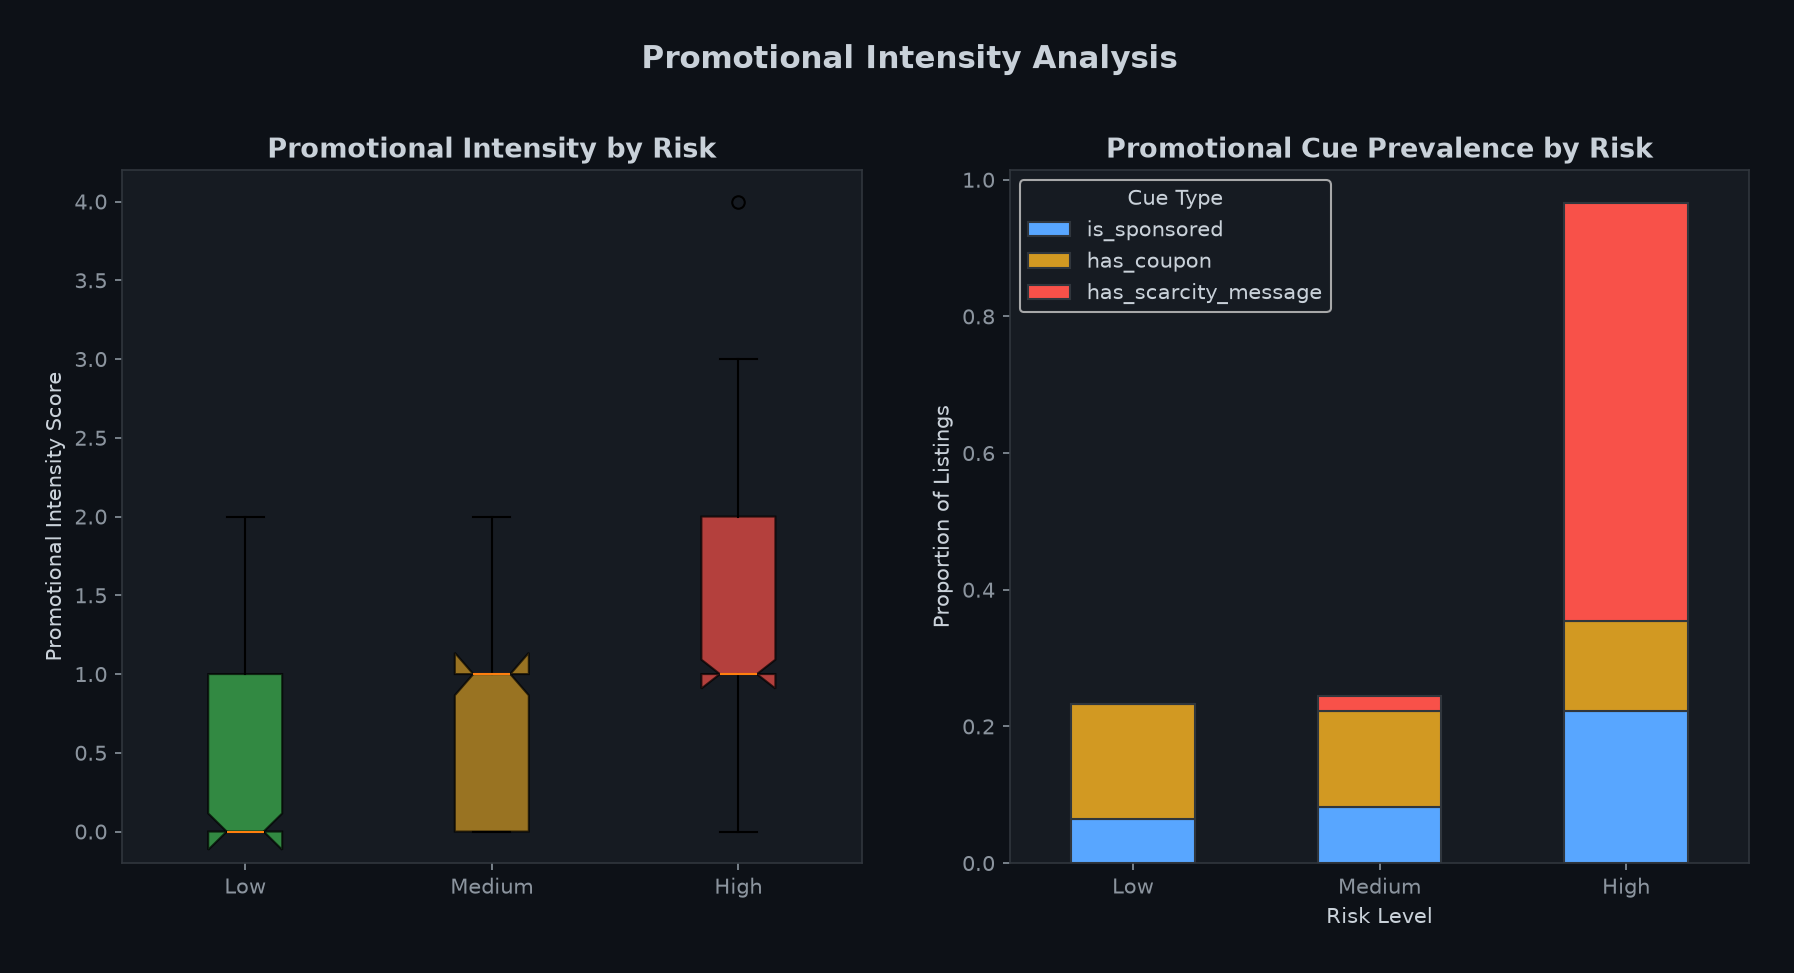


08_trust_vs_urgency.png


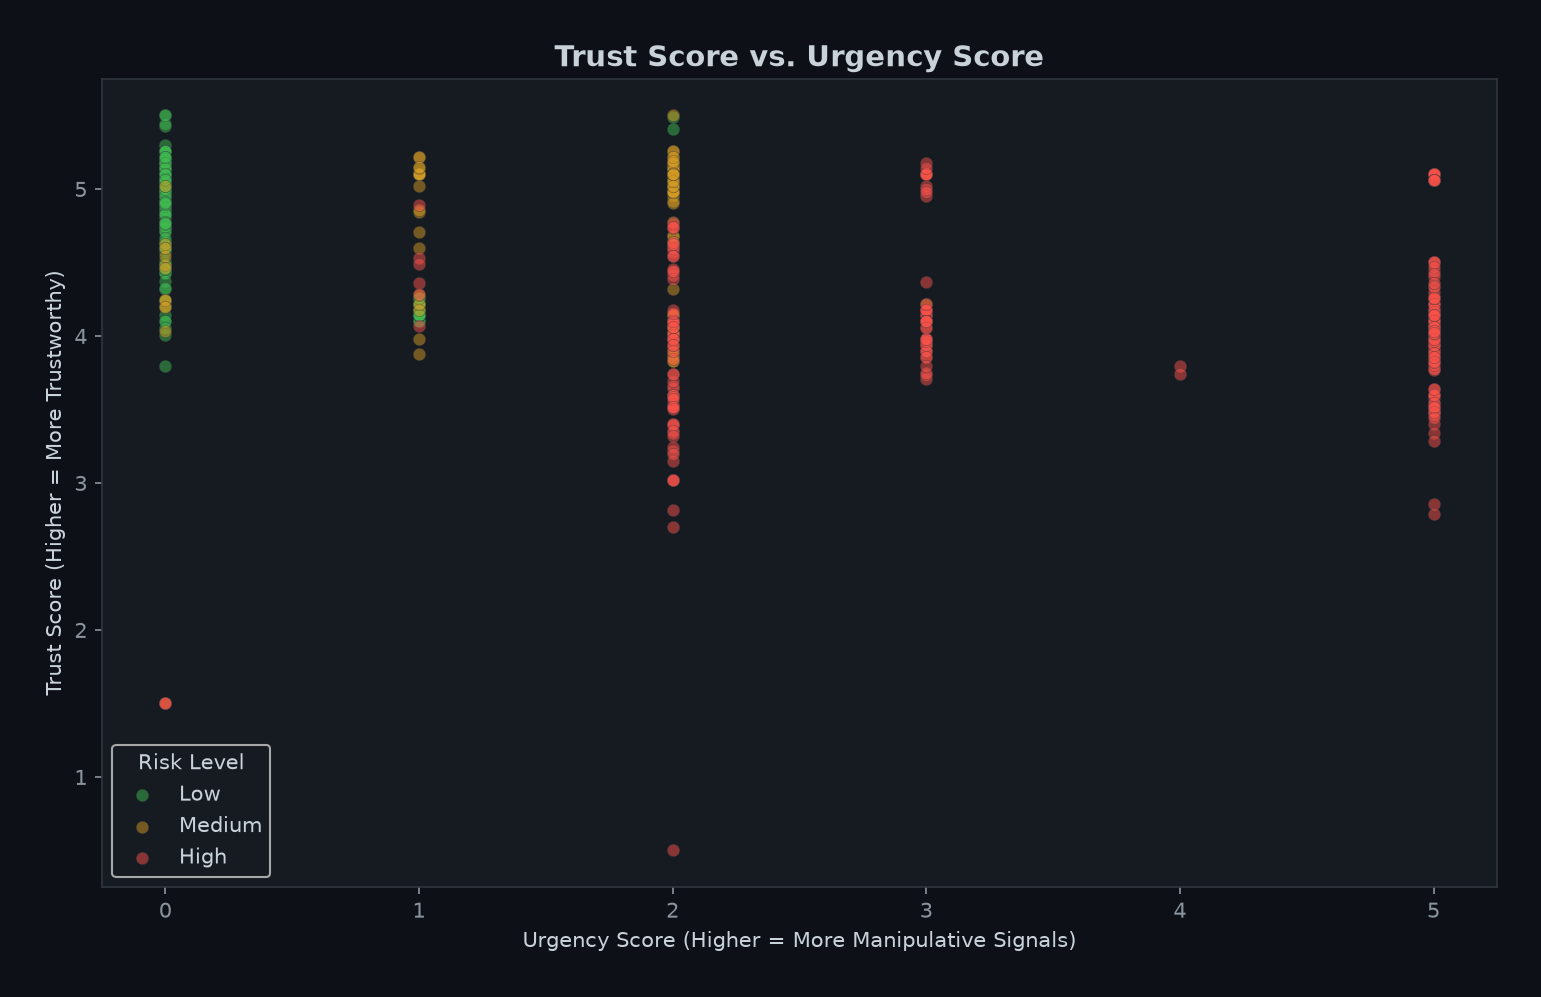


09_price_analysis.png


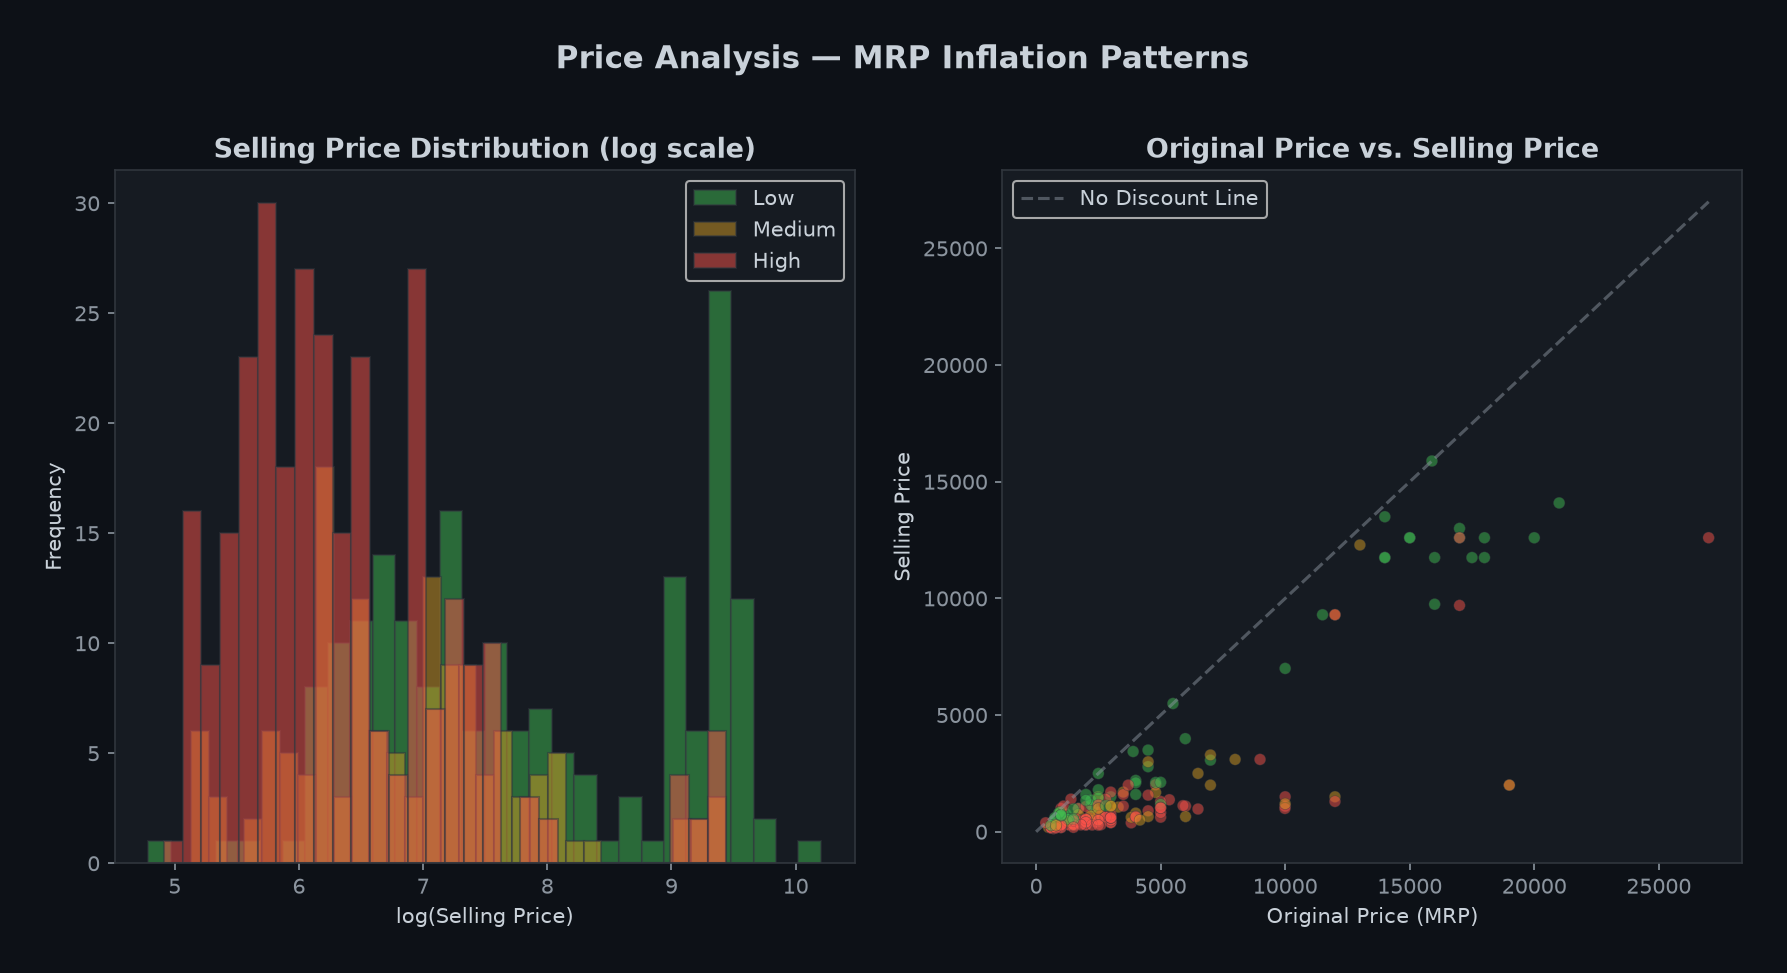


10_feature_distributions.png


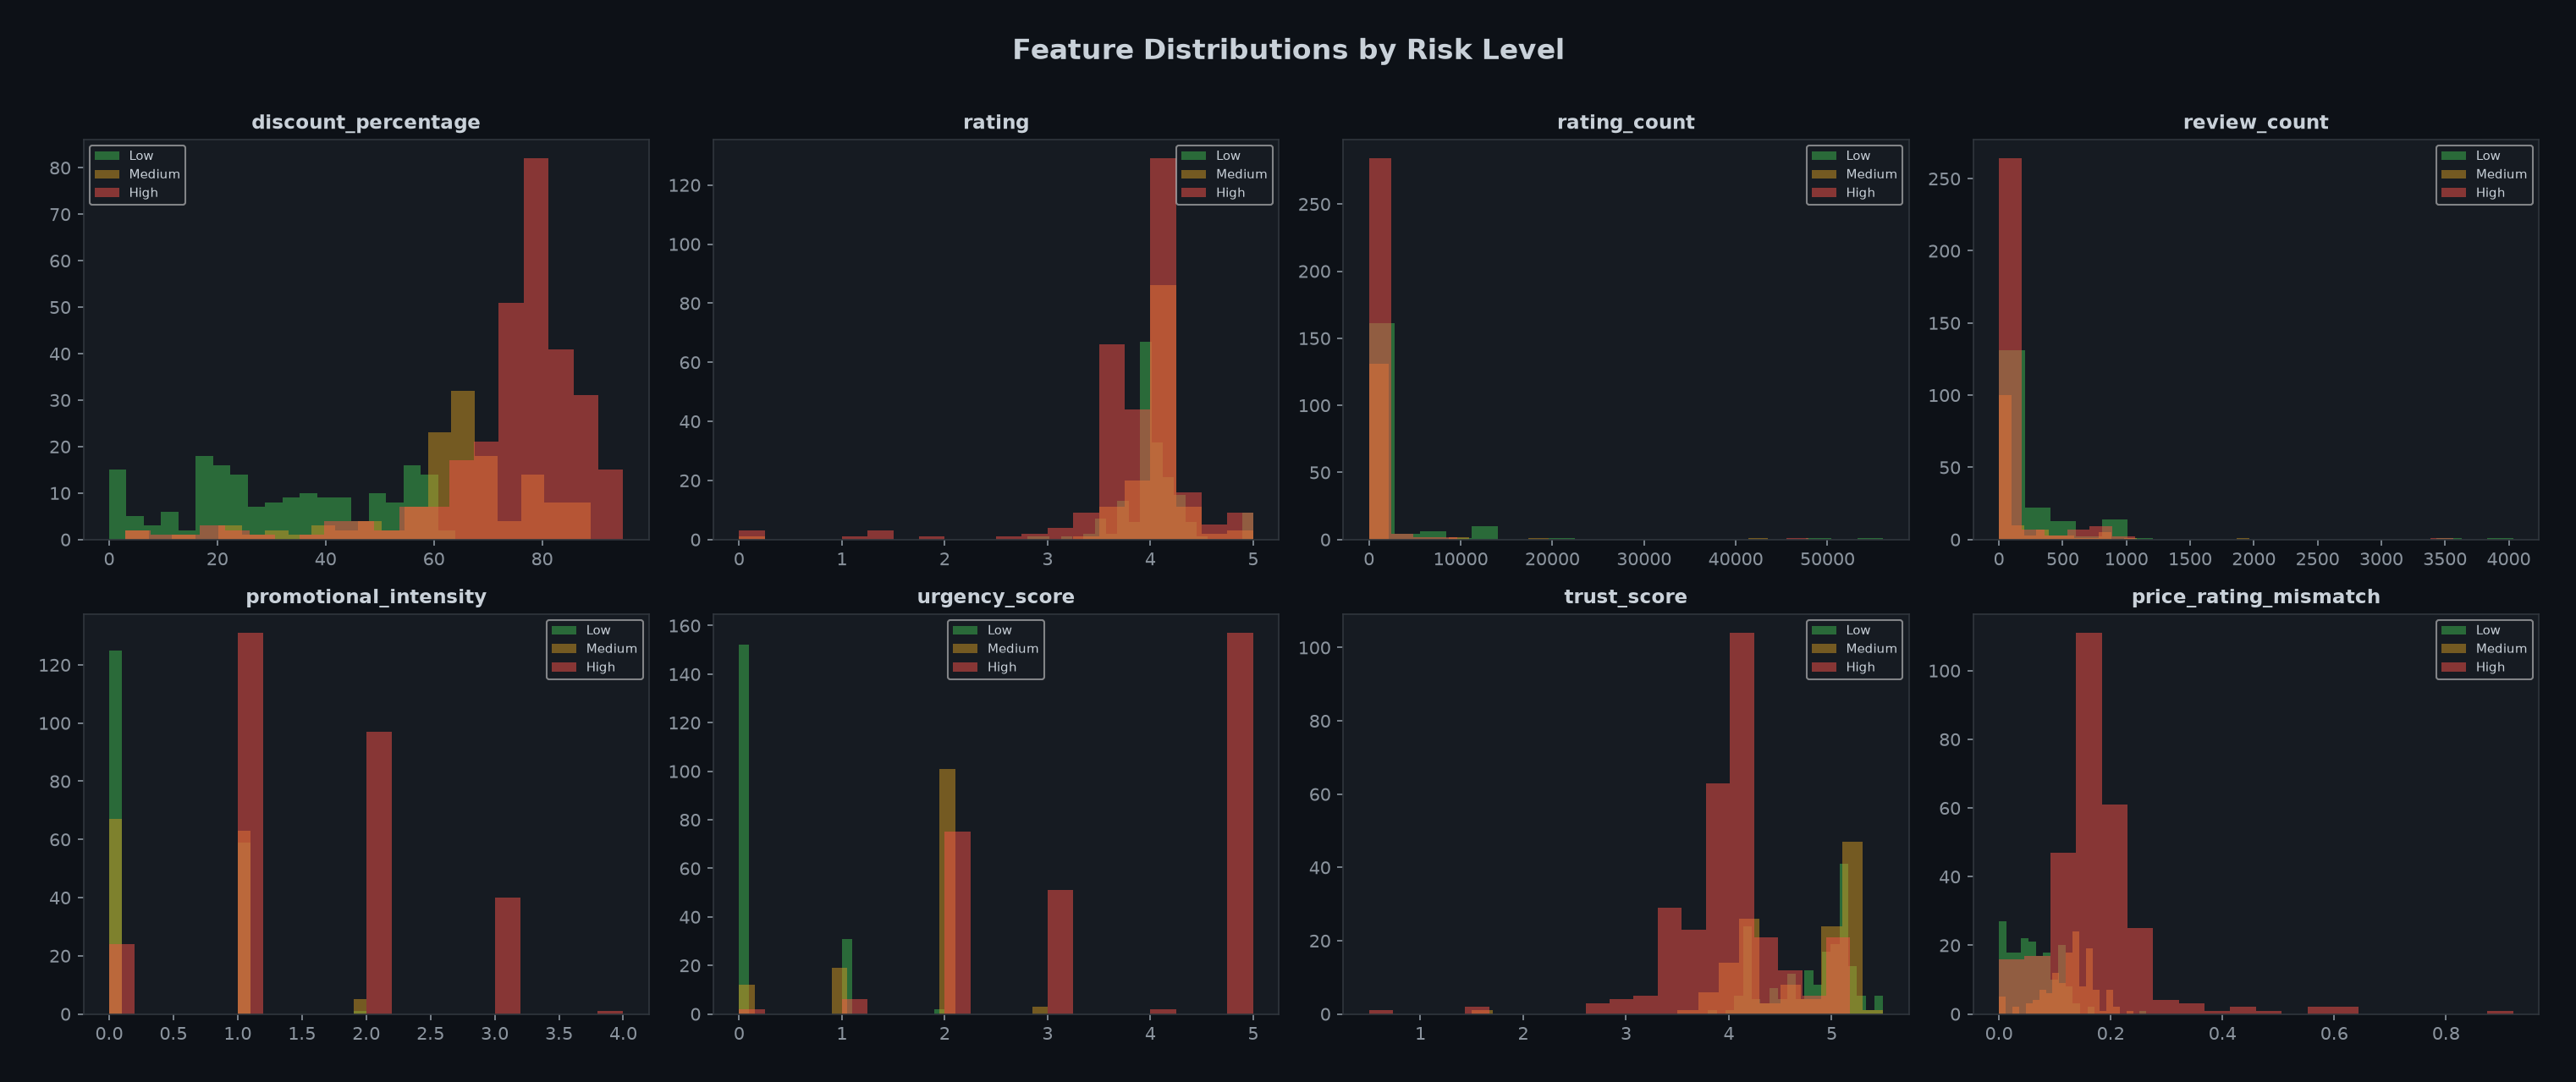

In [18]:
from IPython.display import Image, display
import glob

chart_files = sorted(glob.glob(os.path.join(config.CHARTS_DIR, '*.png')))
for chart in chart_files:
    print(f'\n{os.path.basename(chart)}')
    display(Image(filename=chart, width=700))

---
## Phase 6: Model Training & Evaluation

Trains 4 classifiers with GridSearchCV hyperparameter tuning (5-fold stratified CV):
- Logistic Regression
- Random Forest
- Gradient Boosting
- SVM

Selects the best model by weighted F1-score.

In [19]:
from model import main as model_main
run_phase('Model Training & Evaluation', model_main)


+----------------------------------------------------------+
|  PHASE: Model Training & Evaluation                      |
+----------------------------------------------------------+

╔══════════════════════════════════════════════════════════╗
║  Model Training & Evaluation                             ║
╚══════════════════════════════════════════════════════════╝

Loaded 613 labeled records

  Features: ['selling_price', 'original_price', 'discount_percentage', 'rating', 'rating_count', 'review_count', 'is_sponsored', 'promotional_badge_count', 'has_scarcity_message', 'has_coupon', 'has_return_policy', 'free_delivery', 'delivery_days', 'promotional_intensity', 'price_rating_mismatch', 'review_to_rating_ratio', 'urgency_score', 'trust_score']
  Target classes: [np.str_('Low'), np.str_('Medium'), np.str_('High')]
  Class distribution: {np.int64(0): np.int64(185), np.int64(1): np.int64(135), np.int64(2): np.int64(293)}

  Train: 490 | Test: 123
MODEL TRAINING & HYPERPARAMETER TUNING

──

({'Logistic Regression': {'model': LogisticRegression(C=10, max_iter=1000, random_state=42),
   'scaler': StandardScaler(),
   'best_params': {'C': 10, 'solver': 'lbfgs'},
   'accuracy': 0.9349593495934959,
   'precision': 0.934675839066083,
   'recall': 0.9349593495934959,
   'f1_weighted': 0.9343504163786578,
   'roc_auc': 0.9876522420747462,
   'cv_mean': np.float64(0.9652116668034022),
   'cv_std': np.float64(0.024806445754596274),
   'y_pred': array([1, 2, 0, 2, 0, 2, 1, 2, 2, 0, 0, 0, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2,
          2, 2, 2, 1, 1, 0, 1, 0, 1, 2, 2, 0, 1, 2, 2, 1, 0, 0, 2, 0, 2, 1,
          0, 2, 2, 2, 2, 0, 0, 2, 2, 1, 1, 0, 0, 1, 2, 2, 2, 0, 2, 2, 0, 2,
          1, 2, 1, 1, 2, 0, 2, 0, 2, 2, 1, 1, 2, 2, 1, 0, 0, 2, 0, 2, 2, 2,
          2, 1, 2, 2, 0, 0, 2, 0, 1, 2, 2, 0, 2, 0, 0, 2, 2, 0, 0, 1, 2, 1,
          0, 2, 1, 2, 0, 0, 1, 2, 2, 1, 0, 0, 0]),
   'y_proba': array([[8.92070503e-05, 9.47906364e-01, 5.20044290e-02],
          [4.55235194e-05, 3.65841987e-01, 6.341

### Preview Model Results

,accuracy,precision,recall,f1_weighted,roc_auc,cv_mean,cv_std
Logistic Regression,0.9350,0.9347,0.9350,0.9344,0.9877,0.9652,0.0248
Random Forest,0.9268,0.9262,0.9268,0.9264,0.9767,0.9691,0.0173
Gradient Boosting,0.9268,0.9262,0.9268,0.9264,0.9672,0.9714,0.0199
SVM,0.9675,0.9687,0.9675,0.9673,0.9969,0.9653,0.0314



confusion_matrices.png


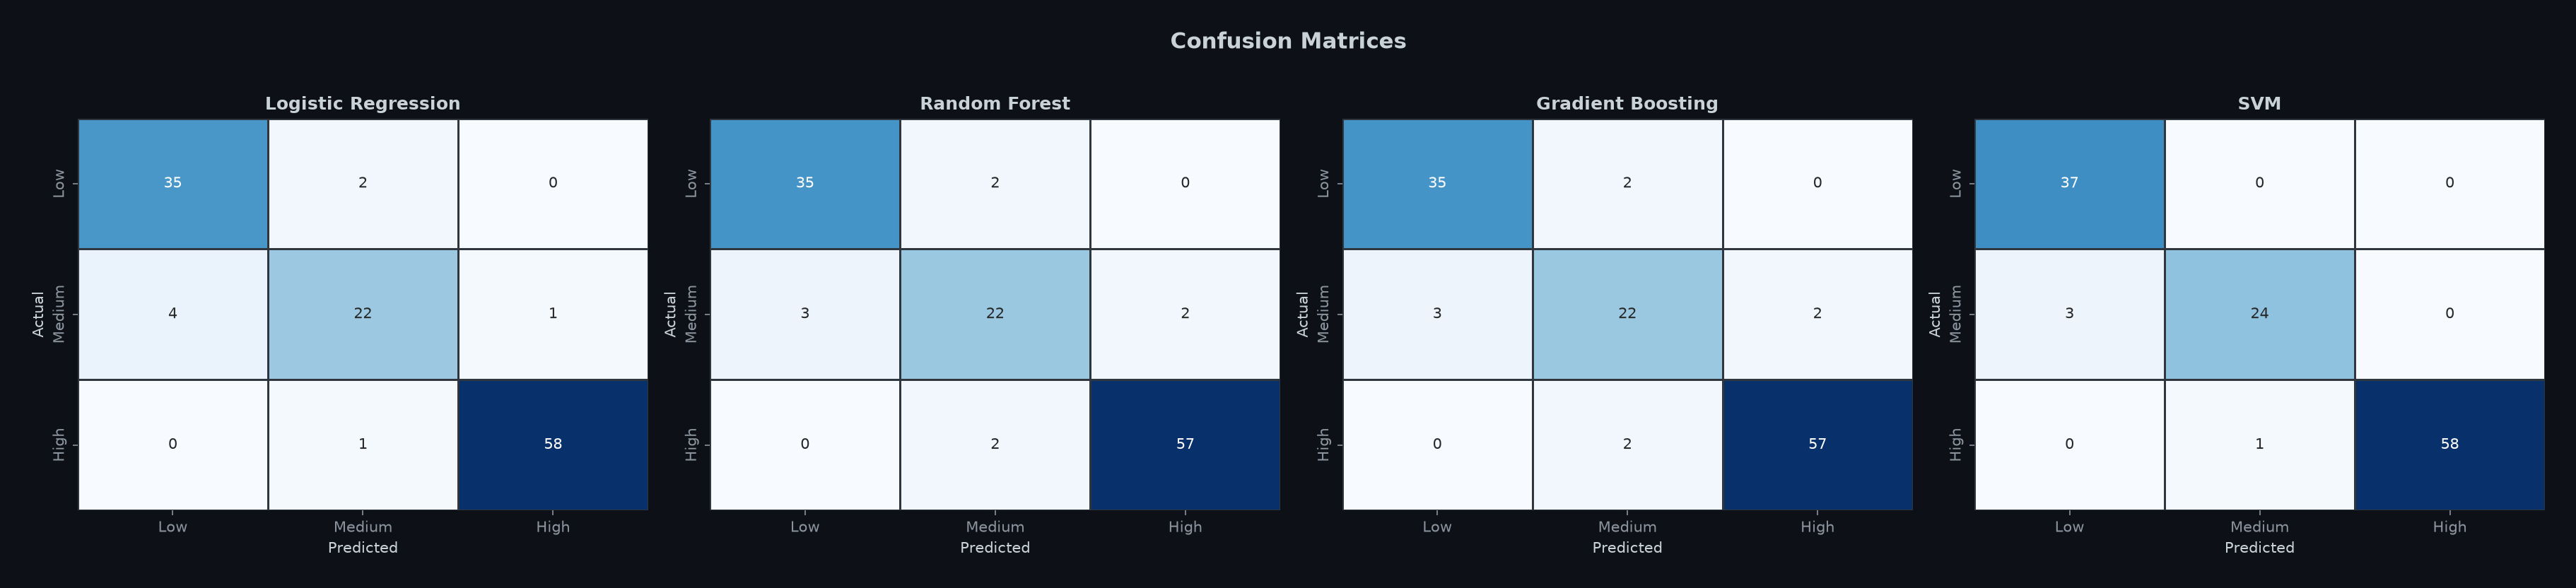


feature_importance.png


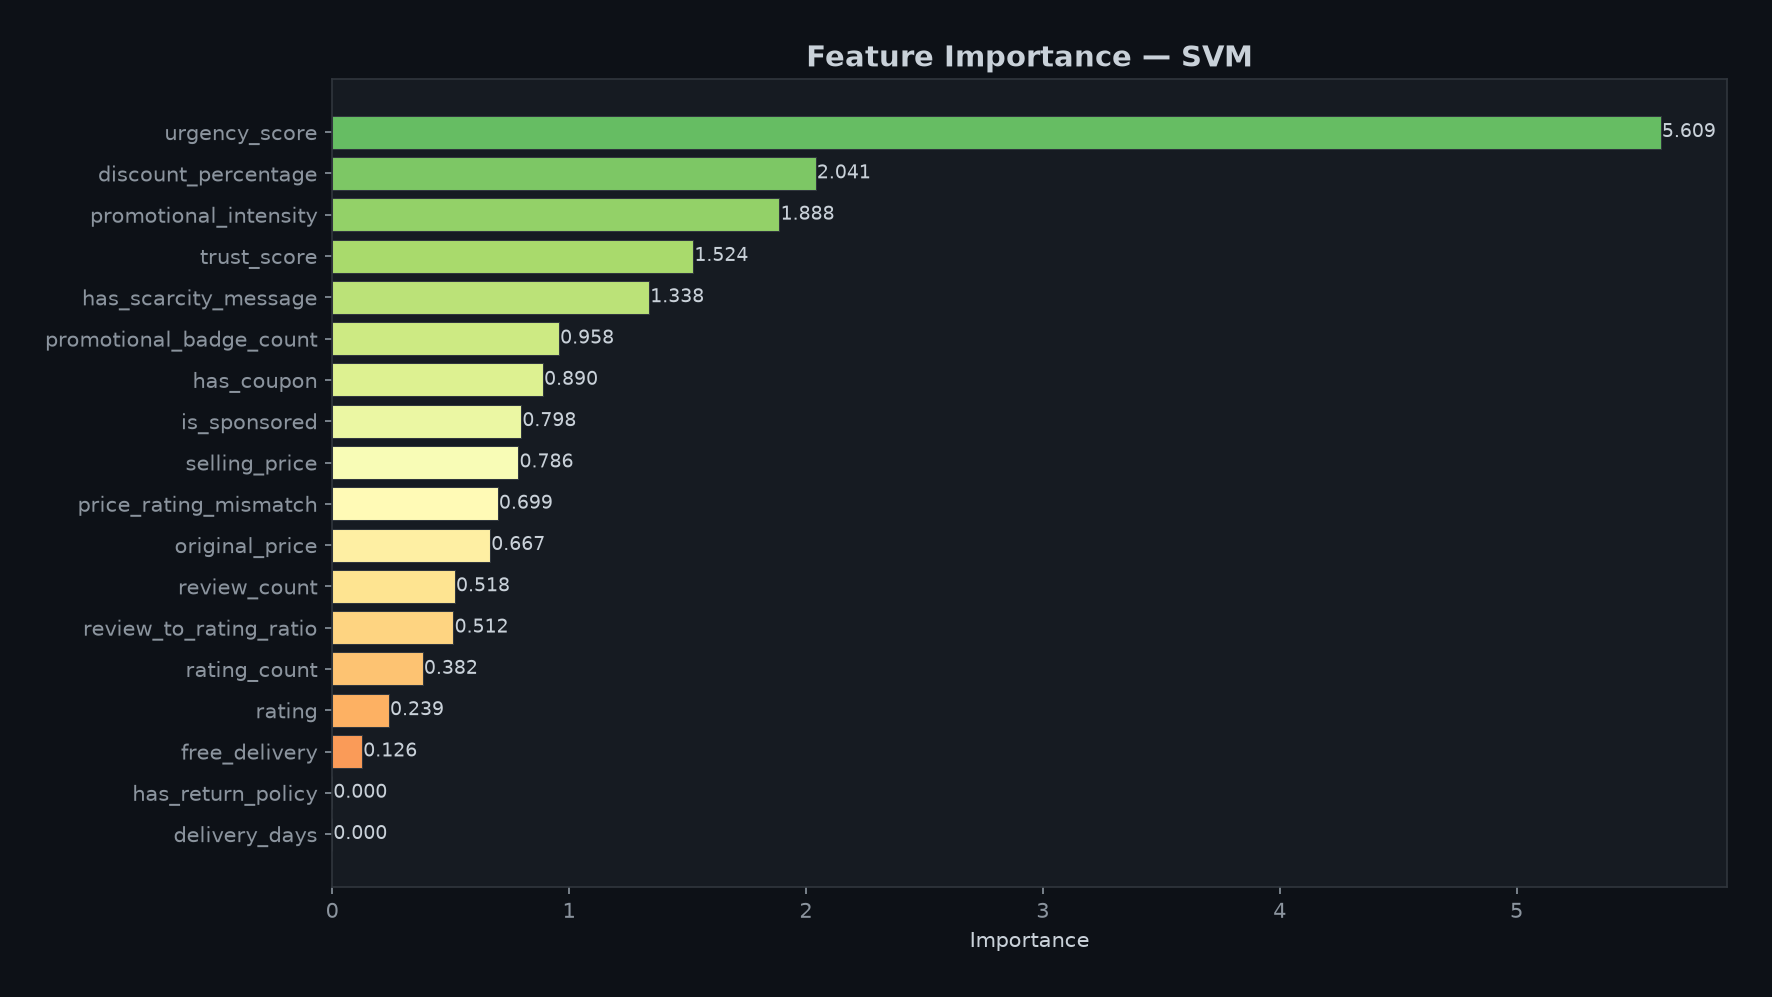


model_comparison.png


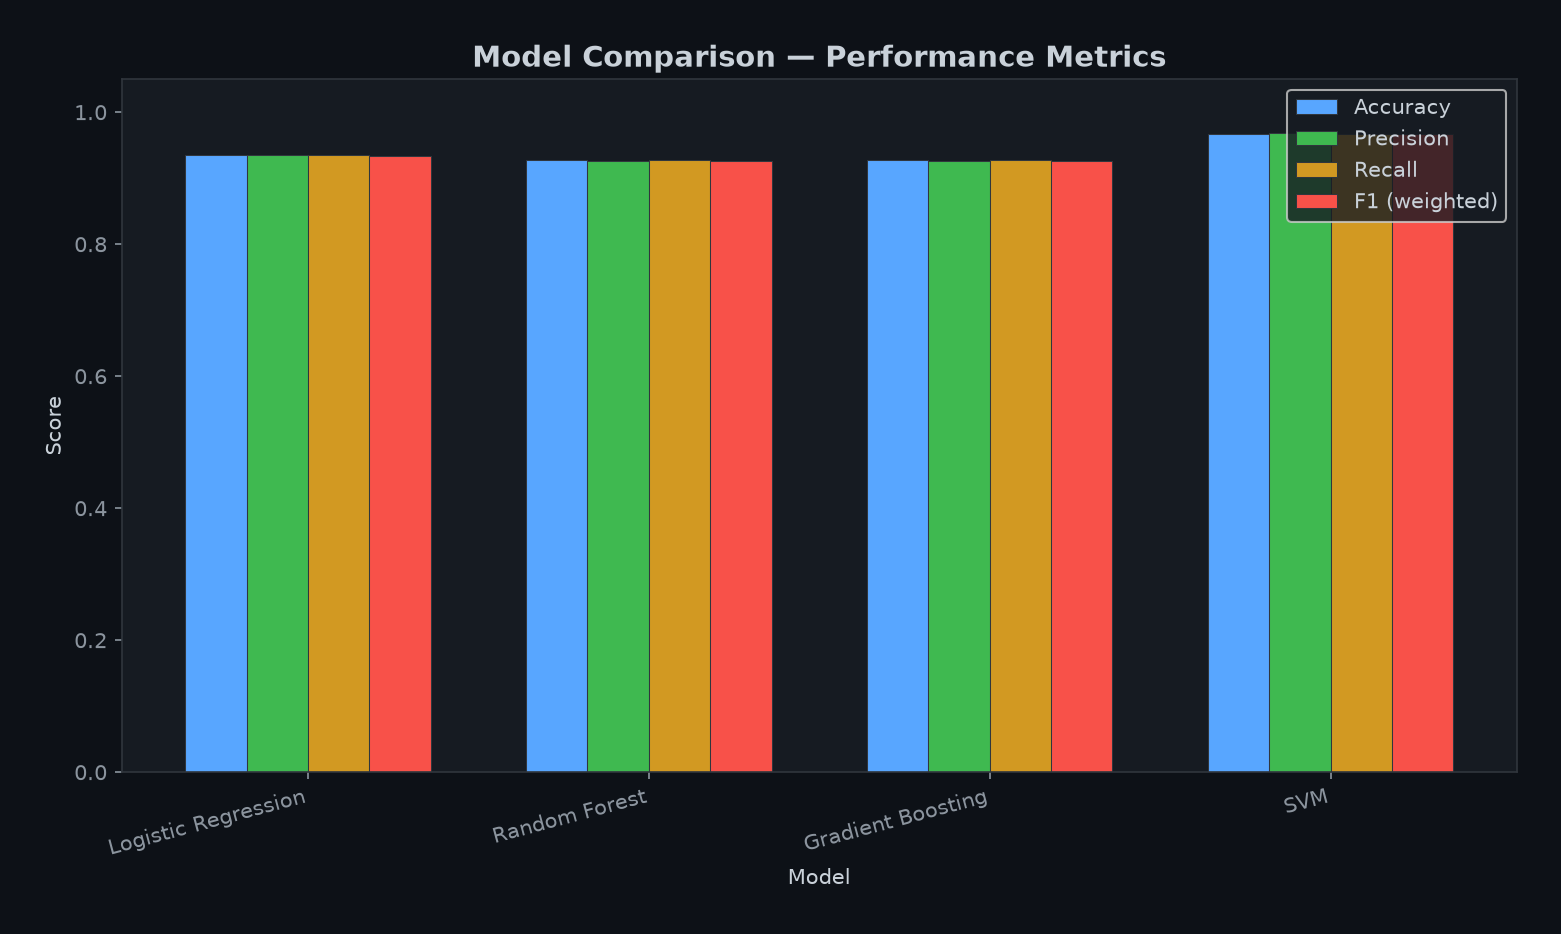

In [20]:
import json
import pandas as pd
from IPython.display import Image, display

# Model comparison table (scalar metrics only)
metrics_path = os.path.join(config.MODEL_DIR, 'all_model_metrics.json')
if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        metrics = json.load(f)
    scalar_cols = ['accuracy', 'precision', 'recall', 'f1_weighted', 'roc_auc', 'cv_mean', 'cv_std']
    rows = {}
    for model_name, model_data in metrics.items():
        rows[model_name] = {k: model_data[k] for k in scalar_cols if k in model_data}
    df_metrics = pd.DataFrame(rows).T
    display(df_metrics)

# Confusion matrices and feature importance
for img_name in ['confusion_matrices.png', 'feature_importance.png', 'model_comparison.png']:
    img_path = os.path.join(config.MODEL_DIR, img_name)
    if os.path.exists(img_path):
        print(f'\n{img_name}')
        display(Image(filename=img_path, width=700))

---
## Phase 7: Report Generation

Generates a comprehensive analytics report in Markdown format at `src/REPORT.md`.

In [21]:
from generate_report import generate_report
run_phase('Report Generation', generate_report)


+----------------------------------------------------------+
|  PHASE: Report Generation                                |
+----------------------------------------------------------+

╔══════════════════════════════════════════════════════════╗
║  Generating Analytics Report                             ║
╚══════════════════════════════════════════════════════════╝


✓ Report saved to d:\Study Material\BA\Dark Patterns\src\REPORT.md
  Sections: Executive Summary, Dataset, Key Findings, Model Performance, Recommendations, Methodology

[OK] Report Generation -- COMPLETE


'd:\\Study Material\\BA\\Dark Patterns\\src\\REPORT.md'

---
## Pipeline Complete

All phases have been executed. Here's a summary of outputs:

In [22]:
print('=' * 60)
print('  PIPELINE COMPLETE -- ALL PHASES FINISHED')
print('=' * 60)
print()
print(f'  Charts:      src/output/charts/')
print(f'  Model:       src/output/model_results/')
print(f'  Report:      src/REPORT.md')
print(f'  Dashboard:   src/dashboard.html')
print(f'  Data:        data/')
print()
print('Open src/dashboard.html in a browser for the interactive dashboard.')

  PIPELINE COMPLETE -- ALL PHASES FINISHED

  Charts:      src/output/charts/
  Model:       src/output/model_results/
  Report:      src/REPORT.md
  Dashboard:   src/dashboard.html
  Data:        data/

Open src/dashboard.html in a browser for the interactive dashboard.
